# 🌳 Feature Exploration & Extraction

Notebook này trình bày quy trình trích chọn 23 thuộc tính đặc trưng của cây (Geometry, Color, Texture, Shape) với log chi tiết và minh họa hình ảnh.

In [1]:
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Thêm thư mục src vào PYTHONPATH để có thể import các module của dự án
notebook_dir = Path(".").resolve()
root_dir = notebook_dir.parent
sys.path.append(str(root_dir / "src"))

from features.extractor import extract, FEATURE_NAMES
print(f"[SUCCESS] Đã load module trích chọn với {len(FEATURE_NAMES)} thuộc tính.")

[SUCCESS] Đã load module trích chọn với 23 thuộc tính.


## 1. Visualize quy trình Tiền xử lý
Trước khi trích chọn, chúng ta cần xem cách hệ thống tạo **Mask** (mặt nạ) để tách biệt cây khỏi nền đen. Mask này là cơ sở cho hầu hết các tính toán hình học và hình dạng.

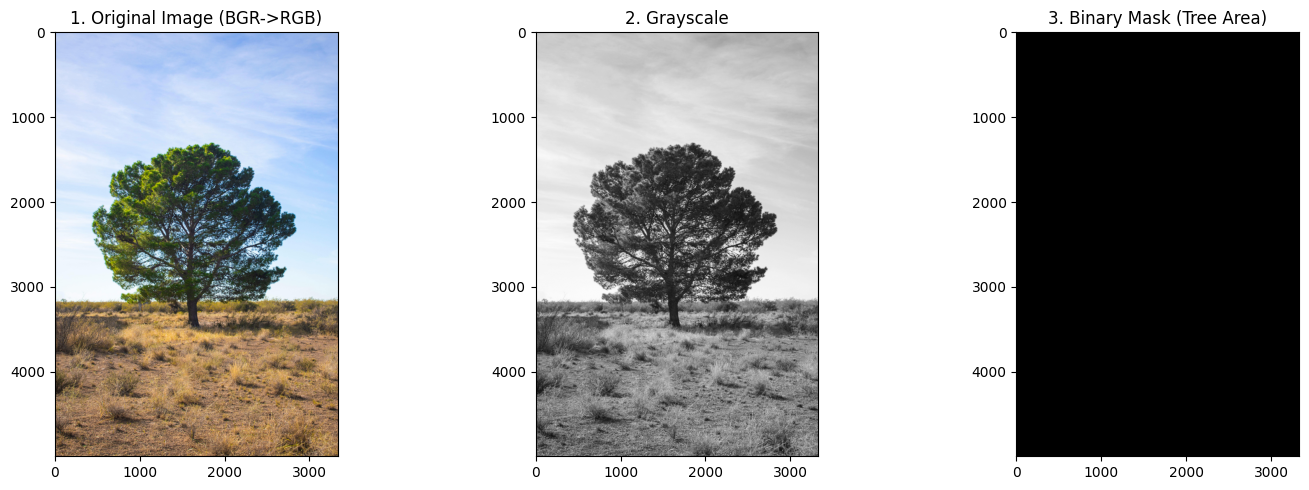

In [9]:
# Chọn một ảnh mẫu từ data/raw
sample_img_path = root_dir / "data/raw/10.jpg"

if not sample_img_path.exists():
    print(f"[ERROR] Không tìm thấy ảnh tại: {sample_img_path}")
else:
    # Đọc ảnh
    img = cv2.imread(str(sample_img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Tiền xử lý tạo mask
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
    
    # Hiển thị trực quan
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title("1. Original Image (BGR->RGB)")
    plt.imshow(img_rgb)
    
    plt.subplot(1, 3, 2)
    plt.title("2. Grayscale")
    plt.imshow(gray, cmap='gray')
    
    plt.subplot(1, 3, 3)
    plt.title("3. Binary Mask (Tree Area)")
    plt.imshow(mask, cmap='gray')
    plt.tight_layout()
    plt.show()

## 2. Trích chọn thuộc tính với Log chi tiết
Chúng ta sẽ chạy hàm `extract` nhưng bổ sung các bước log để theo dõi dữ liệu đi qua từng module: Geometry -> Color -> Texture -> Shape.

In [10]:
def extract_with_detailed_logs(path):
    """
    Hàm bọc (wrapper) để hiển thị log chi tiết từng bước trích chọn.
    """
    print(f"🚀 BẮT ĐẦU TRÍCH CHỌN: {Path(path).name}")
    print("="*50)
    
    # Đọc ảnh
    img = cv2.imread(str(path))
    if img is None: 
        print("[FAIL] Không thể đọc ảnh.")
        return None
    
    # Import các module trích chọn
    from features.geometry import extract_geometry
    from features.color import extract_color
    from features.texture import extract_texture
    from features.shape import extract_shape
    
    # Bước 1: Geometry
    print("STEP 1: Trích chọn đặc trưng Hình học (Geometry)...")
    geo = extract_geometry(img)
    print(f"      > Kết quả (5 giá trị): {geo}")
    
    # Bước 2: Color
    print("STEP 2: Trích chọn đặc trưng Màu sắc (Color)...")
    col = extract_color(img)
    print(f"      > Chỉ số cơ bản: {col[:4]}")
    print(f"      > Hue Histogram (5 bins): {col[4:]}")
    
    # Bước 3: Texture
    print("STEP 3: Trích chọn đặc trưng Vân bề mặt (Texture)...")
    tex = extract_texture(img)
    print(f"      > Kết quả (4 giá trị): {tex}")
    
    # Bước 4: Shape
    print("STEP 4: Trích chọn đặc trưng Hình dạng (Shape)...")
    shp = extract_shape(img)
    print(f"      > Kết quả (5 giá trị): {shp}")
    
    # Tổng hợp
    vector = np.array(geo + col + tex + shp, dtype=np.float32)
    print("="*50)
    print(f"✅ HOÀN TẤT: Tổng cộng {len(vector)} đặc trưng đã được trích chọn.")
    return vector

final_vector = extract_with_detailed_logs(sample_img_path)

🚀 BẮT ĐẦU TRÍCH CHỌN: 10.jpg
STEP 1: Trích chọn đặc trưng Hình học (Geometry)...
      > Kết quả (5 giá trị): [1.4998498949264485, 1.0, 1.0, 1.0, 0.3275532126426697]
STEP 2: Trích chọn đặc trưng Màu sắc (Color)...
      > Chỉ số cơ bản: [0.3730017330519408, 0.32826960999577676, 0.2597846401373193, 0.47974194426090255]
      > Hue Histogram (5 bins): [1.0, 0.16488580405712128, 0.6408882141113281, 0.7138609290122986, 0.0]
STEP 3: Trích chọn đặc trưng Vân bề mặt (Texture)...
      > Kết quả (4 giá trị): [0.5800589485653347, 0.1326291192432461, 0.10867835667513297, 0.9611356797039305]
STEP 4: Trích chọn đặc trưng Hình dạng (Shape)...
      > Kết quả (5 giá trị): [0.03716945720622159, 0.11583624920952496, 1.6220693079963227, 1.0, 0.7539822368615504]
✅ HOÀN TẤT: Tổng cộng 23 đặc trưng đã được trích chọn.


## 3. Bảng tổng hợp Kết quả
Hiển thị vector đặc trưng cuối cùng dưới dạng bảng để dễ dàng quan sát giá trị của từng thuộc tính cụ thể.

In [11]:
import pandas as pd

if final_vector is not None:
    # Tạo DataFrame để hiển thị đẹp mắt
    df_features = pd.DataFrame({
        "STT": range(1, len(FEATURE_NAMES) + 1),
        "Feature Name": FEATURE_NAMES,
        "Raw Value": final_vector
    })
    
    print("\n--- BẢNG GIÁ TRỊ THUỘC TÍNH (RAW) ---")
    display(df_features.style.background_gradient(cmap='Greens', subset=['Raw Value']))
else:
    print("Không có dữ liệu để hiển thị.")


--- BẢNG GIÁ TRỊ THUỘC TÍNH (RAW) ---


,STT,Feature Name,Raw Value
0,1,height_width_ratio,1.499850
1,2,canopy_density,1.000000
2,3,trunk_width_ratio,1.000000
3,4,canopy_symmetry,1.000000
4,5,branch_angle_variance,0.327553
5,6,primary_green_hue,0.373002
6,7,green_saturation,0.328270
7,8,leaf_color_variance,0.259785
8,9,brown_gray_ratio,0.479742
9,10,color_hist_bin_1,1.000000


## 4. Minh hoạ trực quan (Visualizing the algorithms)
Dưới đây là các trực quan hóa giúp hiểu rõ hơn thuật toán đã "nhìn" thấy gì khi tính toán Geometry, Shape và Color.

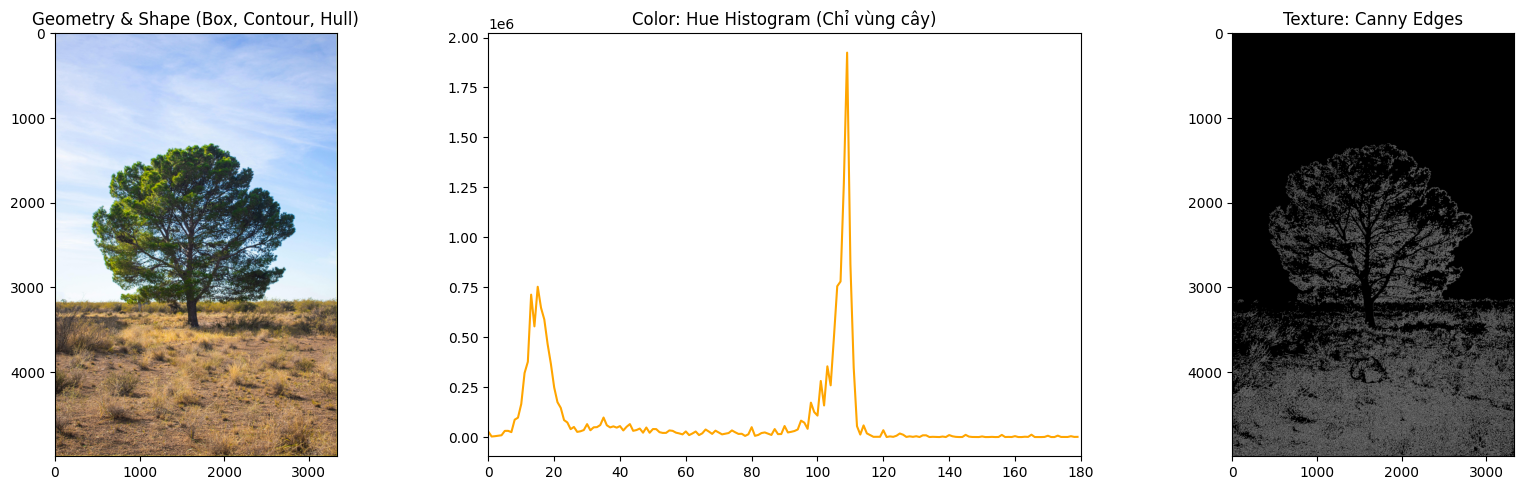

In [12]:
# Trực quan hoá các đặc trưng cơ bản
plt.figure(figsize=(18, 5))

# 1. Geometry & Shape: Tìm Contours (chỉ lấy tree từ mask)
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if len(contours) > 0:
    largest_contour = max(contours, key=cv2.contourArea)
    
    # Vẽ Bounding Box và Contour
    x, y, w, h = cv2.boundingRect(largest_contour)
    img_geom = img_rgb.copy()
    cv2.rectangle(img_geom, (x, y), (x+w, y+h), (255, 0, 0), 2) # Xanh: Bounding Reac
    cv2.drawContours(img_geom, [largest_contour], -1, (0, 255, 0), 2) # Xanh lá: Contour
    
    # Convex Hull
    hull = cv2.convexHull(largest_contour)
    cv2.drawContours(img_geom, [hull], -1, (255, 255, 0), 2) # Vàng: Convex Hull
    
    plt.subplot(1, 3, 1)
    plt.title("Geometry & Shape (Box, Contour, Hull)")
    plt.imshow(img_geom)
    
# 2. Color: Histogram HSV
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
hist_h = cv2.calcHist([hsv_img], [0], mask, [180], [0, 180])
plt.subplot(1, 3, 2)
plt.title("Color: Hue Histogram (Chỉ vùng cây)")
plt.plot(hist_h, color='orange')
plt.xlim([0, 180])

# 3. Texture: Canny Edges (Một khía cạnh của texture)
edges = cv2.Canny(gray, 100, 200)
edges = cv2.bitwise_and(edges, edges, mask=mask) # Chỉ lấy edge trong vùng cây
plt.subplot(1, 3, 3)
plt.title("Texture: Canny Edges")
plt.imshow(edges, cmap='gray')

plt.tight_layout()
plt.show()

## 5. Đi sâu vào Trực quan hoá các đặc trưng Màu sắc (Color Features)
Trong file `src/features/color.py`, thuật toán chia màu sắc làm 4 thành phần chính được minh hoạ dưới đây:
1. **Giá trị H & S trung bình (`mean_h`, `mean_s`)**: Tính trung bình kênh Hue (Màu) và Tương phản (Saturation) để ra màu sắc chủ đạo của cây.
2. **Độ biến thiên kênh màu Xanh lá (`leaf_var`)**: Cây cối có đặc trưng chính là màu xanh lá, việc phân tích nguyên kênh Green (trong hệ RGB) giúp đo lường mức độ biến động màu sắc của tán lá.
3. **Tỷ lệ màu Nâu/Xám (`bg_ratio`)**: Phát hiện và tính tỷ lệ các pixel thuộc màu gỗ, gốc cây, cành cây (màu xám nhạt hoặc nâu).
4. **Biểu đồ Hue 5 dải (`hue_hist`)**: Khác với độ phân giải đầy đủ (180 bins), thuật toán gom nhóm màu sắc của cây vào 5 dải (bins) màu chính (ví dụ: Vàng cam, Vàng chanh, Xanh lục, Xanh lam, Vàng) để so sánh nhanh chóng đặc trưng chung của cái cây.

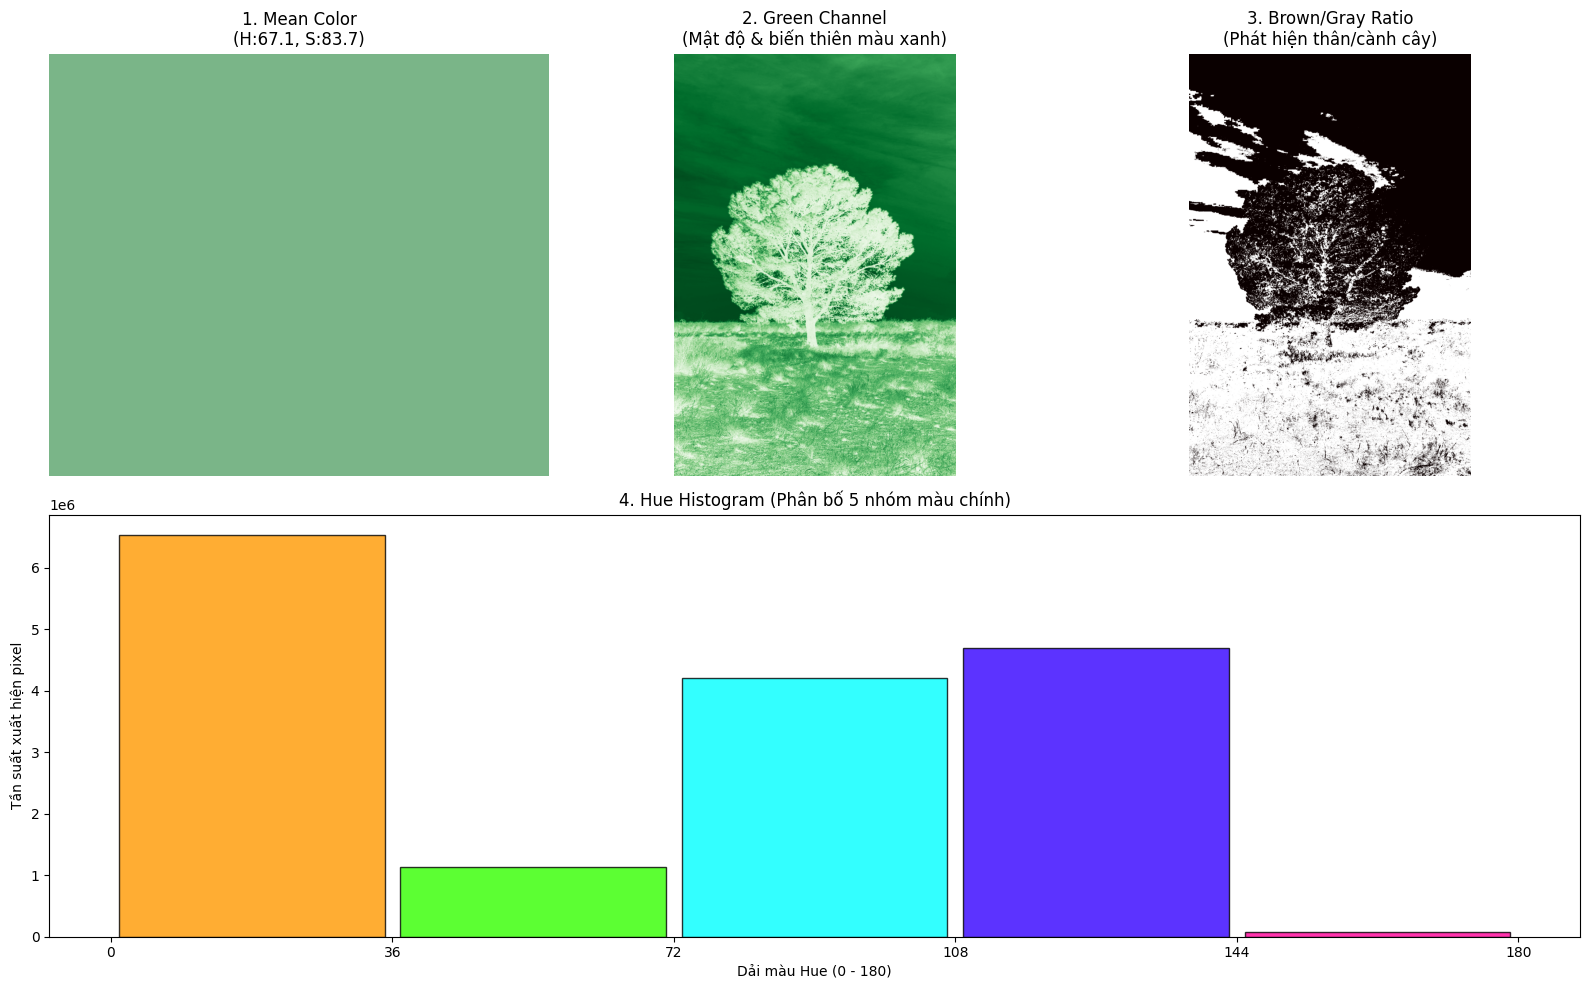

In [13]:
import matplotlib.patches as patches

# Lấy lại Mask, HSV, RGB và Green channel
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
green_channel = img[:, :, 1]

masked_pixels_hsv = img_hsv[mask > 0]

# --- Giải mã 4 thành phần màu sắc ---
# 1. Primary Metrics (Mean Hue & Saturation)
mean_h = np.mean(masked_pixels_hsv[:, 0])
mean_s = np.mean(masked_pixels_hsv[:, 1])
mean_v = np.mean(masked_pixels_hsv[:, 2]) # Lấy thêm V để vẽ minh hoạ
# Đổi màu trung bình về RGB để hiển thị
mean_color_hsv = np.uint8([[[mean_h, mean_s, mean_v]]])
mean_color_rgb = cv2.cvtColor(mean_color_hsv, cv2.COLOR_HSV2RGB)[0][0] / 255.0

# 2. Leaf Color Variance
green_masked = cv2.bitwise_and(green_channel, green_channel, mask=mask)

# 3. Brown / Gray Ratio (Mask cho vùng màu cành/thân cây)
h = img_hsv[:, :, 0]
s = img_hsv[:, :, 1]
# Điều kiện lọc y hệt file `src/features/color.py`
brown_mask = (h >= 5) & (h <= 30) & (s >= 20) & (s <= 150)
gray_mask = (s < 40)
branch_trunk_mask = np.uint8((brown_mask | gray_mask) & (mask > 0)) * 255

# 4. Hue Histogram (5 Bins)
hist_h_5bins = cv2.calcHist([img_hsv], [0], mask, [5], [0, 180]).flatten()

# --- VẼ BIỂU ĐỒ TRỰC QUAN ---
plt.figure(figsize=(16, 10))

# 1. Màu sắc chủ đạo (Mean Color)
ax1 = plt.subplot(2, 3, 1)
ax1.set_title(f"1. Mean Color\n(H:{mean_h:.1f}, S:{mean_s:.1f})")
rect = patches.Rectangle((0, 0), 1, 1, facecolor=mean_color_rgb)
ax1.add_patch(rect)
ax1.axis('off')

# 2. Kênh màu xanh lá (Độ biến thiên)
plt.subplot(2, 3, 2)
plt.title("2. Green Channel\n(Mật độ & biến thiên màu xanh)")
plt.imshow(green_masked, cmap='Greens')
plt.axis('off')

# 3. Tỷ lệ nâu/xám (Thân, Cành, Lá úa)
plt.subplot(2, 3, 3)
plt.title("3. Brown/Gray Ratio\n(Phát hiện thân/cành cây)")
plt.imshow(branch_trunk_mask, cmap='hot') # Hiện màu nóng ở những chỗ là cành/thân
plt.axis('off')

# 4. Color Histogram (5 bins)
plt.subplot(2, 1, 2)
plt.title("4. Hue Histogram (Phân bố 5 nhóm màu chính)")
bin_edges = np.linspace(0, 180, 6)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Tuỳ chỉnh màu cho từng cột bin (cho giống màu gốc Hue)
bin_colors = [cv2.cvtColor(np.uint8([[[c, 255, 255]]]), cv2.COLOR_HSV2RGB)[0][0] / 255.0 for c in bin_centers]
plt.bar(bin_centers, hist_h_5bins, width=(180/5)-2, color=bin_colors, edgecolor='black', alpha=0.8)

plt.xlabel("Dải màu Hue (0 - 180)")
plt.ylabel("Tần suất xuất hiện pixel")
plt.xticks(bin_edges)

plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(3330.5), np.float64(4995.5), np.float64(-0.5))

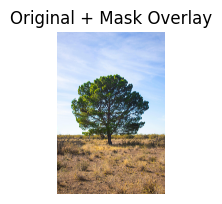

In [14]:
overlay = img_rgb.copy()
overlay[mask == 0] = overlay[mask == 0] * 0.2  # làm tối nền

plt.subplot(2, 4, 1)
plt.title("Original + Mask Overlay")
plt.imshow(overlay)
plt.axis('off')

(np.float64(-0.5), np.float64(3330.5), np.float64(4995.5), np.float64(-0.5))

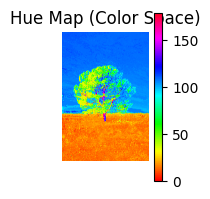

In [16]:
plt.subplot(2, 4, 2)
plt.title("Hue Map (Color Space)")
plt.imshow(img_hsv[:, :, 0], cmap='hsv')
plt.colorbar()
plt.axis('off')

Text(0, 0.5, 'Saturation')

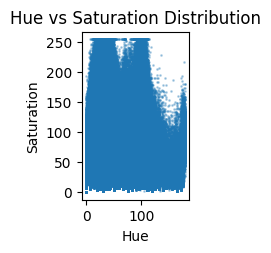

In [17]:
h_vals = masked_pixels_hsv[:, 0]
s_vals = masked_pixels_hsv[:, 1]

plt.subplot(2, 4, 3)
plt.title("Hue vs Saturation Distribution")
plt.scatter(h_vals, s_vals, s=1, alpha=0.3)
plt.xlabel("Hue")
plt.ylabel("Saturation")

(array([3.50000e+01, 3.57000e+02, 3.33500e+03, 1.62000e+04, 4.95580e+04,
        1.15952e+05, 2.14551e+05, 3.12197e+05, 3.58704e+05, 3.65405e+05,
        3.44520e+05, 3.19584e+05, 3.09597e+05, 2.98759e+05, 2.98885e+05,
        3.00630e+05, 2.98725e+05, 3.00651e+05, 3.10112e+05, 3.15585e+05,
        3.20349e+05, 3.23134e+05, 3.33218e+05, 3.44038e+05, 3.52090e+05,
        4.24569e+05, 3.48661e+05, 3.36270e+05, 3.13828e+05, 2.86907e+05,
        2.55533e+05, 2.22012e+05, 1.92039e+05, 1.93089e+05, 2.47103e+05,
        2.39542e+05, 1.97013e+05, 2.83036e+05, 5.50367e+05, 6.55252e+05,
        6.05139e+05, 6.72748e+05, 6.45279e+05, 8.21714e+05, 8.57503e+05,
        6.39512e+05, 4.85457e+05, 4.05873e+05, 4.47839e+05, 1.09220e+05]),
 array([  3.  ,   8.04,  13.08,  18.12,  23.16,  28.2 ,  33.24,  38.28,
         43.32,  48.36,  53.4 ,  58.44,  63.48,  68.52,  73.56,  78.6 ,
         83.64,  88.68,  93.72,  98.76, 103.8 , 108.84, 113.88, 118.92,
        123.96, 129.  , 134.04, 139.08, 144.12, 149.

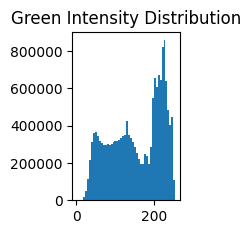

In [18]:
plt.subplot(2, 4, 4)
plt.title("Green Intensity Distribution")
plt.hist(green_channel[mask > 0], bins=50)

(np.float64(-0.5), np.float64(3330.5), np.float64(4995.5), np.float64(-0.5))

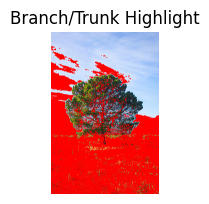

In [19]:
highlight = img_rgb.copy()
highlight[branch_trunk_mask > 0] = [255, 0, 0]  # đỏ

plt.subplot(2, 4, 5)
plt.title("Branch/Trunk Highlight")
plt.imshow(highlight)
plt.axis('off')

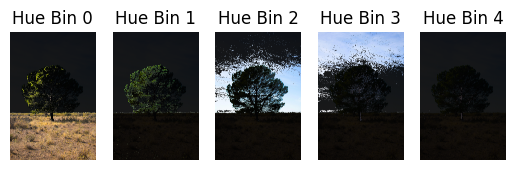

In [20]:
bin_masks = []
bin_edges = np.linspace(0, 180, 6)

for i in range(5):
    mask_bin = (img_hsv[:, :, 0] >= bin_edges[i]) & (img_hsv[:, :, 0] < bin_edges[i+1]) & (mask > 0)
    bin_masks.append(mask_bin)

for i, bm in enumerate(bin_masks):
    temp = img_rgb.copy()
    temp[~bm] = temp[~bm] * 0.1

    plt.subplot(2, 5, 6 + i)
    plt.title(f"Hue Bin {i}")
    plt.imshow(temp)
    plt.axis('off')